# **REDES NEURONALES - OPTIMIZACION**

Apellido y Nombre: Vasquez Caiza Juan Marcelo.

Carrera: Ingenieira de Sistemas.

# **IMPORTAMOS LAS LIBRERIAS QUE USAREMOS:**

Cargamos las librerias que vamos a usar:
torch la base que proporciona las funcionalidades necesarias para construir y entrenar redes neuronales. 
torchvision es una libreria especializada en vision por computadora, la utilizamos para simplificar la carga y manipulacion de datos de imagenes. Ofrece: transformacion de datos(Resize, crop, convertir a tensor, Image folder que basandose en la estructura de carpetas asignara categorias).

In [28]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score

import torchvision
from torchvision.datasets import ImageFolder
from torchvision import transforms

Preparamos las imagenes utilizando transformaciones para redimensionar y normalizar las imagenes. transforms.Compose es un clase de torchvision que permite encadenar varias transformaciones en un solo objeto.

In [29]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

Guardamos las rutas locales.

In [30]:
train_root_dir = 'C:/Users/asus/Documents/SIS420-Inteligencia-Artificial-I-/Laboratorios/Laboratorio6/train'
val_root_dir = 'C:/Users/asus/Documents/SIS420-Inteligencia-Artificial-I-/Laboratorios/Laboratorio6/val'

Creamos los datasets y tambien las clases, ImageFolder permite leer imagenes ordenadas en subcarpetas, donde cada subcarpeta representa una clase, y le asignara una etiqueta numerica (0,1,2,etc). Carga las rutas(root) y aplica transformaciones a las imagenes.

In [31]:
trainset = ImageFolder(root=train_root_dir, transform=transform)
valset = ImageFolder(root=val_root_dir, transform=transform)

classes = trainset.classes

Haremos uso de un dataset que consta de 5 categorias de fotos de animales.

In [32]:
print(f"Clases detectadas: {classes}")
print(f"Imágenes de entrenamiento: {len(trainset)}")
print(f"Imágenes de validación: {len(valset)}")

Clases detectadas: ['cat', 'dog', 'elephant', 'horse', 'lion']
Imágenes de entrenamiento: 13474
Imágenes de validación: 1497


Con el siguiente codigo se facilita el proceso de cargar y preparar los datos para el entrenamiento, el Dataloader nos permite iterar sobre los datos en pequeños paquetes o lotes. 

In [33]:
dataloader = {
    'train': torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True),
    'val': torch.utils.data.DataLoader(valset, batch_size=1000, shuffle=False)
}

DEFINIMOS EL MODELO

Como en el anterior laboratorio definimos el numero de entradas, la capa oculta y las salidas. 

In [34]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

def build_model(D_in=32*32*3, H=100, D_out=5):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    ).cuda()

ENTRENAMIENTO DEL MODELO

In [35]:
def fit(model, dataloader, optimizer, epochs=80, log_each=10, early_stopping=10):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    
    for e in range(1, epochs + 1):
        _l, _acc = [], []
        model.train()
        
        # Bucle de entrenamiento
        for x_b, y_b in dataloader['train']:
            # Mover los datos a la GPU
            x_b, y_b = x_b.cuda().view(-1, 32*32*3), y_b.cuda()
            
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
            
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        
        # Bucle de validación
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                # Mover los datos a la GPU
                x_b, y_b = x_b.cuda().view(-1, 32*32*3), y_b.cuda()
                
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        
        # Guardar el mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        
        step += 1
        
        # Early stopping
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
            
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")
            
    # Cargar el mejor modelo guardado
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}


HACEMOS USO DE LOS OPTIMIZADORES

Aqui realizaremos la comparacion del uso de optimizadores y una grafica comparativa.

DESCENDO DE GRADIENTE ESTOCASTICO - SGD

In [36]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
hist_sgd = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.20427 en epoch 1
Mejor modelo guardado con acc 0.21631 en epoch 2
Mejor modelo guardado con acc 0.21922 en epoch 4
Mejor modelo guardado con acc 0.22110 en epoch 6
Mejor modelo guardado con acc 0.23222 en epoch 7
Mejor modelo guardado con acc 0.23371 en epoch 8
Mejor modelo guardado con acc 0.24370 en epoch 9
Mejor modelo guardado con acc 0.25937 en epoch 10
Epoch 10/80 loss 1.53329 acc 0.35149 val_loss 1.54642 val_acc 0.25937
Mejor modelo guardado con acc 0.27186 en epoch 11
Mejor modelo guardado con acc 0.29654 en epoch 12
Mejor modelo guardado con acc 0.31315 en epoch 13
Mejor modelo guardado con acc 0.32119 en epoch 14
Mejor modelo guardado con acc 0.32771 en epoch 15
Mejor modelo guardado con acc 0.34437 en epoch 16
Mejor modelo guardado con acc 0.36051 en epoch 17
Mejor modelo guardado con acc 0.36700 en epoch 18
Mejor modelo guardado con acc 0.37288 en epoch 20
Epoch 20/80 loss 1.41777 acc 0.44076 val_loss 1.44197 val_acc 0.37288
Mejor modelo guar

C:\Users\asus\AppData\Local\Temp\ipykernel_12576\3801940921.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


SGD - CON MOMENTO

In [37]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_momentum = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.27358 en epoch 1
Mejor modelo guardado con acc 0.36701 en epoch 2
Mejor modelo guardado con acc 0.40550 en epoch 3
Mejor modelo guardado con acc 0.41745 en epoch 4
Mejor modelo guardado con acc 0.47540 en epoch 5
Mejor modelo guardado con acc 0.51310 en epoch 6
Mejor modelo guardado con acc 0.57835 en epoch 10
Epoch 10/80 loss 1.09453 acc 0.55879 val_loss 1.08969 val_acc 0.57835
Mejor modelo guardado con acc 0.58262 en epoch 12
Mejor modelo guardado con acc 0.58626 en epoch 13
Mejor modelo guardado con acc 0.60444 en epoch 14
Mejor modelo guardado con acc 0.60800 en epoch 15
Mejor modelo guardado con acc 0.62041 en epoch 19
Epoch 20/80 loss 0.92605 acc 0.63326 val_loss 1.04852 val_acc 0.57844
Mejor modelo guardado con acc 0.62691 en epoch 23
Mejor modelo guardado con acc 0.63649 en epoch 25
Mejor modelo guardado con acc 0.63736 en epoch 27
Mejor modelo guardado con acc 0.64298 en epoch 29
Epoch 30/80 loss 0.82731 acc 0.67301 val_loss 0.94131 val_acc 0.63

C:\Users\asus\AppData\Local\Temp\ipykernel_12576\3801940921.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


RMSProp

In [38]:
model = build_model()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
hist_rms = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.35936 en epoch 1
Mejor modelo guardado con acc 0.43536 en epoch 2
Mejor modelo guardado con acc 0.50683 en epoch 3
Mejor modelo guardado con acc 0.54344 en epoch 4
Mejor modelo guardado con acc 0.57573 en epoch 6
Mejor modelo guardado con acc 0.60192 en epoch 9
Epoch 10/80 loss 0.97353 acc 0.60688 val_loss 1.02718 val_acc 0.58926
Mejor modelo guardado con acc 0.63808 en epoch 15
Epoch 20/80 loss 0.85543 acc 0.66020 val_loss 1.29859 val_acc 0.52076
Entrenamiento detenido en epoch 25 por no mejorar en 10 epochs seguidas


C:\Users\asus\AppData\Local\Temp\ipykernel_12576\3801940921.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


ADAM

In [39]:
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
hist_adam = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.44114 en epoch 1
Mejor modelo guardado con acc 0.54329 en epoch 2
Mejor modelo guardado con acc 0.61847 en epoch 5
Epoch 10/80 loss 0.90746 acc 0.63677 val_loss 0.98449 val_acc 0.59299
Mejor modelo guardado con acc 0.62805 en epoch 11
Mejor modelo guardado con acc 0.63074 en epoch 12
Mejor modelo guardado con acc 0.65955 en epoch 13
Mejor modelo guardado con acc 0.66560 en epoch 18
Epoch 20/80 loss 0.78149 acc 0.68179 val_loss 1.06320 val_acc 0.60097
Mejor modelo guardado con acc 0.67052 en epoch 24
Epoch 30/80 loss 0.69151 acc 0.72423 val_loss 0.91731 val_acc 0.64026
Entrenamiento detenido en epoch 34 por no mejorar en 10 epochs seguidas


C:\Users\asus\AppData\Local\Temp\ipykernel_12576\3801940921.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


GRAFICAS DE COMPARACION:

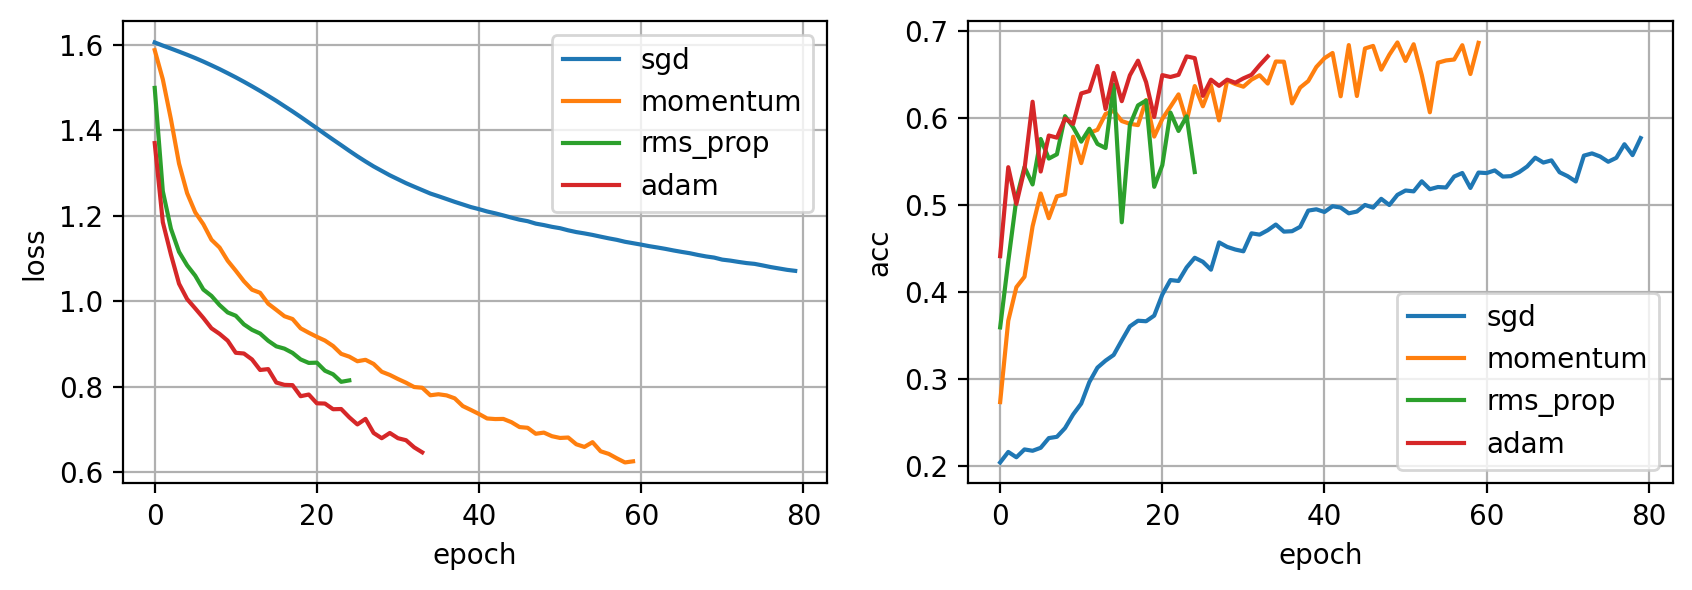

In [40]:
import matplotlib.pyplot as plt

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_sgd['loss'], label="sgd")
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_rms['loss'], label="rms_prop")
ax.plot(hist_adam['loss'], label="adam")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_sgd['val_acc'], label="sgd")
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_rms['val_acc'], label="rms_prop")
ax.plot(hist_adam['val_acc'], label="adam")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()